In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langchain_groq import ChatGroq
import operator 
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

load_dotenv()

True

In [19]:
llm = ChatGroq(model="llama3-8b-8192", verbose=True)

In [20]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [21]:
def chat_node(state: ChatState):
    messages = state['messages']
    
    response = llm.invoke(messages)
    
    return {'messages':[response]}

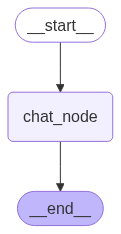

In [22]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_node',chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

chatbot

In [ ]:
thread_id = '1'
while True:
    message = input("Type here: ")

    print("User:", message)

    if message.strip().lower() in ['quit','exit']:
        break
    
    config = {'configurable':{'thread_id':thread_id}}
    response = chatbot.invoke({'messages':[HumanMessage(content=message)]}, config=config)

    print("AI: ", response['messages'][-1].content)

User: Hello my name is Sagar
AI: Nice to meet you, Sagar! It's great to have you here. Is there something I can help you with or would you like to chat a bit and get to know each other?
User: What is my name?
AI: I remember! Your name is Sagar!
User: Are you sure?
AI: Yes, I'm sure! You told me your name is Sagar just a minute ago.
User: What is 10+10?
AI: That's an easy one! The answer is 20!
User: Multiply the result by 67
AI: If we multiply 20 by 67, we get:

20 × 67 = 1340
User: exit


In [25]:
chatbot.invoke({'messages':[HumanMessage(content='What is my name?')]}, config=config)

{'messages': [HumanMessage(content='Hello my name is Sagar', additional_kwargs={}, response_metadata={}, id='b565a52c-9950-438d-81e6-1a30534ec3b7'),
  AIMessage(content="Nice to meet you, Sagar! It's great to have you here. Is there something I can help you with or would you like to chat a bit and get to know each other?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 16, 'total_tokens': 56, 'completion_time': 0.035599356, 'prompt_time': 0.002577484, 'queue_time': 0.05641404, 'total_time': 0.03817684}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_c0b3855449', 'finish_reason': 'stop', 'logprobs': None}, id='run-a8c7c444-1c34-467a-8dcc-cf3f045d9452-0', usage_metadata={'input_tokens': 16, 'output_tokens': 40, 'total_tokens': 56}),
  HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='7767d7d1-a101-4662-96f1-42c7df427af4'),
  AIMessage(content='I remember! Your name is Sagar!', additional

In [24]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hello my name is Sagar', additional_kwargs={}, response_metadata={}, id='b565a52c-9950-438d-81e6-1a30534ec3b7'), AIMessage(content="Nice to meet you, Sagar! It's great to have you here. Is there something I can help you with or would you like to chat a bit and get to know each other?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 16, 'total_tokens': 56, 'completion_time': 0.035599356, 'prompt_time': 0.002577484, 'queue_time': 0.05641404, 'total_time': 0.03817684}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_c0b3855449', 'finish_reason': 'stop', 'logprobs': None}, id='run-a8c7c444-1c34-467a-8dcc-cf3f045d9452-0', usage_metadata={'input_tokens': 16, 'output_tokens': 40, 'total_tokens': 56}), HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='7767d7d1-a101-4662-96f1-42c7df427af4'), AIMessage(content='I remember! Your name is Saga

In [29]:
thread_id = '1'
while True:
    message = input("Type here: ")

    print("User:", message)

    if message.strip().lower() in ['quit','exit']:
        break
    
    config = {'configurable':{'thread_id':thread_id}}
    for message_chunk, metadata in chatbot.stream( 
        {"messages": message},
        stream_mode="messages",
        config=config
    ):
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)

User: Write 5000 big words essay for me
I'd be happy to help you with a 5000-word essay! However, I need to clarify that I'll need to make some assumptions about the topic, purpose, and tone, as you didn't provide specific details. I'll do my best to create a well-structured and coherent essay.

**Topic:** The Impact of Artificial Intelligence on the Job Market and Society

**Purpose:** To examine the effects of artificial intelligence (AI) on the job market and society, exploring the potential benefits and drawbacks of this technological advancement.

**Tone:** Formal and informative, with a neutral perspective.

**Essay:**

The advent of artificial intelligence (AI) has revolutionized various industries and aspects of modern life. AI has the potential to automate tasks, increase efficiency, and provide unprecedented insights. However, the widespread adoption of AI raises concerns about its impact on the job market and society as a whole.

One of the most significant concerns is the p